In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix, ConfusionMatrixDisplay


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/cse422/Dataset/diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [ ]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [ ]:
class_counts = df['diabetes'].value_counts()
print(class_counts)

diabetes
0    91500
1     8500
Name: count, dtype: int64


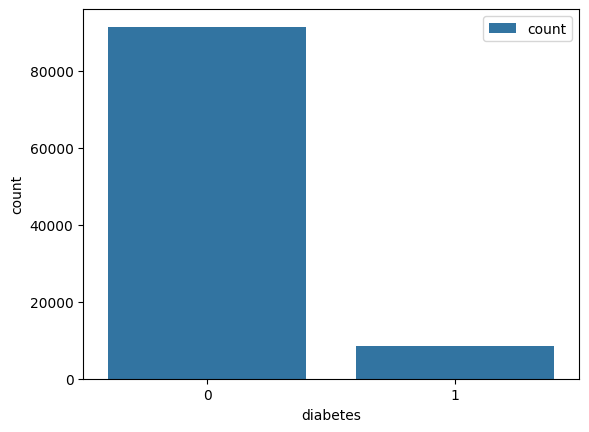

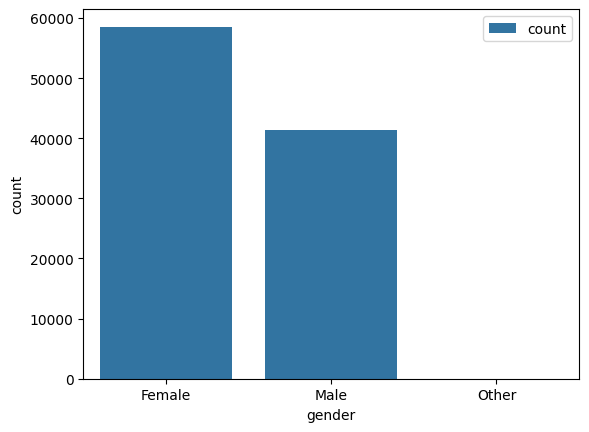

In [ ]:
sns.countplot(x = 'diabetes', data=df, label='count')
plt.show()

# sns.countplot(x = 'smoking_history', data=df, label='count')
# plt.show()

sns.countplot(x = 'gender', data=df, label='count')
plt.show()

In [ ]:
df['gender'].value_counts()

,count
gender,
Female,58552
Male,41430
Other,18


**check wheather there are any null value exist**


In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/cse422/Dataset/diabetes_prediction_dataset.csv')

# Check if any null values exist in the dataset
print(df.isnull().sum())  # Null count per column

# Check if any null value exists in the entire dataset
print(df.isnull().values.any())  # True/False

# Total number of null values in the entire dataset
print(df.isnull().sum().sum())  # Total null count


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
False
0


one hot encoding to smoking history column

In [ ]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# Separate features and target
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

# Encoding gender as binary
X["gender"] = X["gender"].map({"Female": 0, "Male": 1})

# One-hot encoding for smoking_history
X = pd.get_dummies(X, columns=["smoking_history"], drop_first=True)

# Scaling numeric features
# numeric_features = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
# scaler = StandardScaler()
# X[numeric_features] = scaler.fit_transform(X[numeric_features])

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the processed df
X_train.tail()


,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
6265,1.0,49.0,0,0,32.98,5.7,80,False,False,False,True,False
54886,0.0,15.0,0,0,28.10,5.0,159,False,False,False,True,False
76820,1.0,42.0,0,0,26.14,5.8,85,False,False,False,True,False
860,0.0,37.0,0,0,24.96,6.2,158,False,False,False,True,False
15795,0.0,23.0,0,0,27.99,5.0,159,False,False,False,True,False


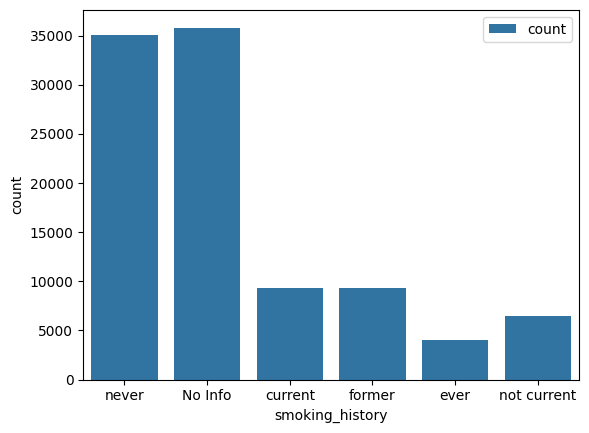

In [ ]:
sns.countplot(x = 'smoking_history', data=df, label='count')
plt.show()

In [ ]:
male_df = df[df['gender'] == 'Male']
female_df = df[df['gender'] == 'Female']
other_df = df[df['gender'] == 'Other']

total_male = len(male_df)
total_female = len(female_df)
total_other = len(other_df)


# print(total_male)
# print(total_female)

male_diabetes = len(male_df[male_df['diabetes']=='1'])
female_diabetes = len(female_df[female_df['diabetes']=='1'])
other_diabetes = len(other_df[other_df['diabetes']=='1'])

# male_smoke = len(male_df[male_df['SMK_stat_type_cd']==3])
# female_smoke = len(female_df[female_df['SMK_stat_type_cd']== 3])

percentage_of_male_diabetes = '{:.1f}'.format((male_diabetes/total_male)*100)
percentage_of_female_diabetes = '{:.1f}'.format((female_diabetes/total_female)*100)

print('Percentage of male who diabetes:', percentage_of_male_diabetes,'%')
print('Percentage of female who diabetes:', percentage_of_female_diabetes,'%')

# percentage_of_male_smoke = '{:.1f}'.format((male_smoke/total_male)*100)
# percentage_of_female_smoke = '{:.1f}'.format((female_smoke/total_female)*100)

# print('Percentage of male who smoke:', percentage_of_male_smoke,'%')
# print('Percentage of female who smoke:', percentage_of_female_smoke,'%')

labels = ['Male', 'Female']
sizes = [percentage_of_male_diabetes, percentage_of_female_diabetes]
colors = ['lightblue', 'lightcoral']
explode = (0, 0.1)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Percentage of Male and Female Who diabetes')
plt.axis('equal')
plt.show()

# labels = ['Male', 'Female']
# sizes = [percentage_of_male_smoke, percentage_of_female_smoke]
# colors = ['lightblue', 'lightcoral']
# explode = (0, 0.1)

# plt.figure(figsize=(8, 6))
# plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
# plt.title('Percentage of Male and Female Who smoke')
# plt.axis('equal')
# plt.show()

Percentage of male who diabetes: 0.0 %
Percentage of female who diabetes: 0.0 %


RuntimeError: In affine_transform: Invalid vertices array.

ValueError: need at least one array to concatenate

<Figure size 800x800 with 1 Axes>

In [ ]:
male_smoke_counts = male_df['SMK_stat_type_cd'].value_counts()
female_smoke_counts = female_df['SMK_stat_type_cd'].value_counts()

male_current_smoker = male_smoke_counts.get(3,0)
male_past_smoker = male_smoke_counts.get(2,0)
male_never_smoke = male_smoke_counts.get(1,0)

female_current_smoker = female_smoke_counts.get(3,0)
female_past_smoker = female_smoke_counts.get(2,0)
female_never_smoke = female_smoke_counts.get(1,0)

print('Number of male who currently smoke:', male_current_smoker)
print('Number of male who quit smoking:', male_past_smoker)
print('Number of male who never smoked:', male_never_smoke)

print('Number of female who currently smoke:', female_current_smoker)
print('Number of female who quit smoking:', female_past_smoker)
print('Number of female who never smoked:', female_never_smoke)

Number of male who currently smoke: 197706
Number of male who quit smoking: 164028
Number of male who never smoked: 164681
Number of female who currently smoke: 16248
Number of female who quit smoking: 10923
Number of female who never smoked: 437760


In [ ]:
df.shape

(100000, 9)

In [ ]:
features = df.shape[1]
print(features)

9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
df1 = df.copy()
df1['gender'] = df['gender'].apply(lambda x: 1 if x=='Male' else 0)
df1['diabetes'] = df['diabetes'].apply(lambda x:1 if x=='Y' else 0)
df1['smoking_history'] = df['smoking_history'].apply(lambda x:1 if x== 3 else 0)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  int64  
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  int64  
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 6.9 MB


In [ ]:
df1.isnull().sum()
total_null_values = df1.isnull().sum().sum()
print('Total null values:', total_null_values)

Total null values: 0


In [ ]:
int(df['HbA1c_level'].mean())
# int(df['triglyceride'].mean())
# int(df['hemoglobin'].mean())
# int(df['urine_protein'].mean())
# int(df['serum_creatinine'].mean())
# int(df['SGOT_AST'].mean())
# int(df['SGOT_ALT'].mean())
# int(df['gamma_GTP'].mean())
# int(df['SMK_stat_type_cd'].mean())

5

In [ ]:
df1['HbA1c_level'] = df1['HbA1c_level'].fillna(np.mean(df1['HbA1c_level']))
# df1['triglyceride'] = df1['triglyceride'].fillna(np.mean(df1['triglyceride']))
# df1['hemoglobin'] = df1['hemoglobin'].fillna(np.mean(df1['hemoglobin']))
# df1['urine_protein'] = df1['urine_protein'].fillna(np.mean(df1['urine_protein']))
# df1['serum_creatinine'] = df1['serum_creatinine'].fillna(np.mean(df1['serum_creatinine']))
# df1['SGOT_AST'] = df1['SGOT_AST'].fillna(np.mean(df1['SGOT_AST']))
# df1['SGOT_ALT'] = df1['SGOT_ALT'].fillna(np.mean(df1['SGOT_ALT']))
# df1['gamma_GTP'] = df1['gamma_GTP'].fillna(np.mean(df1['gamma_GTP']))
# df1['SMK_stat_type_cd'] = df1['SMK_stat_type_cd'].fillna(np.mean(df1['SMK_stat_type_cd']))



In [ ]:
df1.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


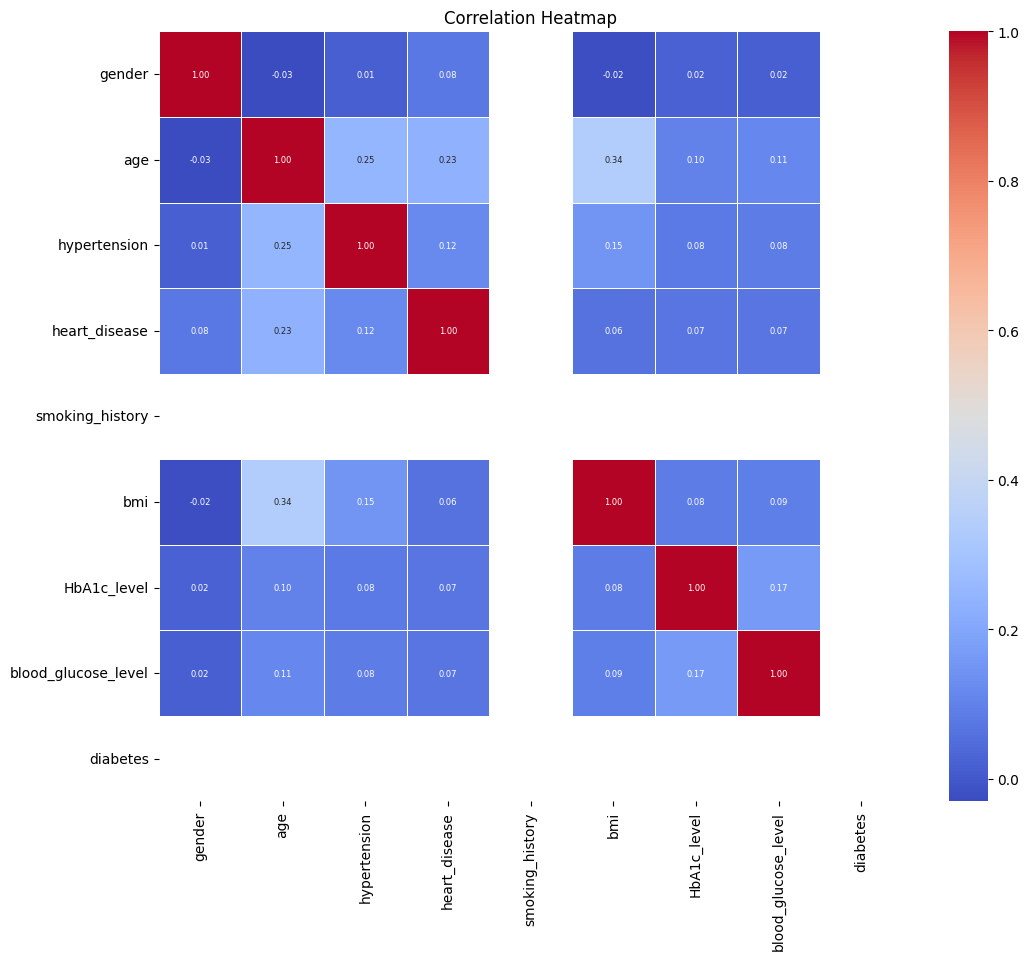

In [ ]:
correlation_matrix = df1.corr()
plt.figure(figsize = (12,10))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths=0.5, annot_kws={"size": 6})
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
data_points = df.shape[0]
print(data_points)

100000


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df1.drop(['diabetes'], axis =1)
y_drink = df1['diabetes']
y_smoke = df1['diabetes']

X_train, X_test,  = train_test_split(X, test_size= 0.3, random_state= 42)

ros_drink = RandomOverSampler(random_state=42)
X_train_resampled_drink = ros_drink.fit_resample(X_train,[])

ros_smoke = RandomOverSampler(random_state=42)
X_train_resampled_smoke , y_train_resampled_smoke = ros_drink.fit_resample(X_train, y_smoke_train)

scaler_drink = StandardScaler()
X_train_standardized_drink = scaler_drink.fit_transform(X_train_resampled_drink)

scaler_smoke = StandardScaler()
X_train_standardized_smoke = scaler_smoke.fit_transform(X_train_resampled_smoke)

X_test_standarized_drink = scaler_drink.transform(X_test)
X_test_standarized_smoke = scaler_smoke.transform(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


ValueError: The target 'y' needs to have more than 1 class. Got 0 class instead

In [ ]:
knn_classifier = KNeighborsClassifier(n_neighbors =3)
knn_classifier.fit(X_train_standardized_drink, y_train_resampled_drink)

knn_pred_drink = knn_classifier.predict(X_test_standarized_drink)

knn_accuracy_drink = accuracy_score(y_drink_test, knn_pred_drink)
class_report_drink = classification_report(y_drink_test, knn_pred_drink)

print("\nFor Drinking Prediction:")
print(f'Accuracy: {knn_accuracy_drink:.4f}')
print('\nClassification Report:')
print(class_report_drink)

knn_classifier = KNeighborsClassifier(n_neighbors =3)
knn_classifier.fit(X_train_standardized_drink, y_train_resampled_drink)

knn_pred_smoke = knn_classifier.predict(X_test_standarized_drink)

knn_accuracy_smoke = accuracy_score(y_smoke_test, knn_pred_smoke)
class_report_smoke = classification_report(y_smoke_test, knn_pred_smoke)

print("\nFor Smoking Prediction:")
print(f'Accuracy: {knn_accuracy_smoke:.4f}')
print('\nClassification Report:')
print(class_report_smoke)


For Drinking Prediction:
Accuracy: 0.6666

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.66      0.66    149147
           1       0.66      0.68      0.67    148257

    accuracy                           0.67    297404
   macro avg       0.67      0.67      0.67    297404
weighted avg       0.67      0.67      0.67    297404


For Smoking Prediction:
Accuracy: 0.5993

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.56      0.69    233390
           1       0.32      0.76      0.45     64014

    accuracy                           0.60    297404
   macro avg       0.61      0.66      0.57    297404
weighted avg       0.77      0.60      0.63    297404



In [ ]:
naive_bayes_classifier = GaussianNB()
naive_bayes_classifier.fit(X_train_standardized_drink, y_train_resampled_drink)

nb_pred_drink = naive_bayes_classifier.predict(X_test_standarized_drink)

nb_accuracy_drink = accuracy_score(y_drink_test, nb_pred_drink)
class_report_drink = classification_report(y_drink_test, nb_pred_drink)

print("\nFor Drinking Prediction:")
print(f'Accuracy: {nb_accuracy_drink:.4f}')
print('\nClassification Report:')
print(class_report_drink)

naive_bayes_classifier = GaussianNB()
naive_bayes_classifier.fit(X_train_standardized_smoke, y_train_resampled_smoke)

nb_pred_smoke = naive_bayes_classifier.predict(X_test_standarized_smoke)

nb_accuracy_smoke = accuracy_score(y_smoke_test, nb_pred_smoke)
class_report_smoke = classification_report(y_smoke_test, nb_pred_smoke)

print("\nFor Smoking Prediction:")
print(f'Accuracy: {nb_accuracy_smoke:.4f}')
print('\nClassification Report:')
print(class_report_smoke)



For Drinking Prediction:
Accuracy: 0.6847

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.71      0.69    149147
           1       0.69      0.66      0.68    148257

    accuracy                           0.68    297404
   macro avg       0.68      0.68      0.68    297404
weighted avg       0.68      0.68      0.68    297404


For Smoking Prediction:
Accuracy: 0.6937

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.66      0.77    233390
           1       0.40      0.80      0.53     64014

    accuracy                           0.69    297404
   macro avg       0.66      0.73      0.65    297404
weighted avg       0.81      0.69      0.72    297404



In [ ]:
logreg_classifier = LogisticRegression(random_state=42)
logreg_classifier.fit(X_train_standardized_drink, y_train_resampled_drink)

logreg_pred_drink = logreg_classifier.predict(X_test_standarized_drink)

logreg_accuracy_drink = accuracy_score(y_drink_test, logreg_pred_drink)
class_report = classification_report(y_drink_test, logreg_pred_drink)

print("\nFor Drinking Prediction:")
print(f'Accuracy: {logreg_accuracy_drink:.4f}')
print('\nClassification Report:')
print(class_report)

logreg_classifier = LogisticRegression(random_state=42)
logreg_classifier.fit(X_train_standardized_smoke, y_train_resampled_smoke)

logreg_pred_smoke = logreg_classifier.predict(X_test_standarized_smoke)

logreg_accuracy_smoke = accuracy_score(y_smoke_test, logreg_pred_smoke)
class_report = classification_report(y_smoke_test, logreg_pred_smoke)

print("\nFor Smoking Prediction:")
print(f'Accuracy: {logreg_accuracy_smoke:.4f}')
print('\nClassification Report:')
print(class_report)


For Drinking Prediction:
Accuracy: 0.7214

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72    149147
           1       0.72      0.72      0.72    148257

    accuracy                           0.72    297404
   macro avg       0.72      0.72      0.72    297404
weighted avg       0.72      0.72      0.72    297404


For Smoking Prediction:
Accuracy: 0.6978

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.65      0.77    233390
           1       0.41      0.88      0.56     64014

    accuracy                           0.70    297404
   macro avg       0.68      0.76      0.66    297404
weighted avg       0.83      0.70      0.72    297404



In [ ]:
# Drinking Prediction with Random Forest
rf_classifier_drink = RandomForestClassifier(random_state=42)
rf_classifier_drink.fit(X_train_standardized_drink, y_train_resampled_drink)

rf_pred_drink = rf_classifier_drink.predict(X_test_standarized_drink)

rf_accuracy_drink = accuracy_score(y_drink_test, rf_pred_drink)
class_report_drink = classification_report(y_drink_test, rf_pred_drink)

print("\nFor Drinking Prediction (Random Forest):")
print(f'Accuracy: {rf_accuracy_drink:.4f}')
print('\nClassification Report:')
print(class_report_drink)

# Smoking Prediction with Random Forest
rf_classifier_smoke = RandomForestClassifier(random_state=42)
rf_classifier_smoke.fit(X_train_standardized_smoke, y_train_resampled_smoke)

rf_pred_smoke = rf_classifier_smoke.predict(X_test_standarized_smoke)

rf_accuracy_smoke = accuracy_score(y_smoke_test, rf_pred_smoke)
class_report_smoke = classification_report(y_smoke_test, rf_pred_smoke)

print("\nFor Smoking Prediction (Random Forest):")
print(f'Accuracy: {rf_accuracy_smoke:.4f}')
print('\nClassification Report:')
print(class_report_smoke)



For Drinking Prediction (Random Forest):
Accuracy: 0.7280

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.72      0.73    149147
           1       0.72      0.73      0.73    148257

    accuracy                           0.73    297404
   macro avg       0.73      0.73      0.73    297404
weighted avg       0.73      0.73      0.73    297404


For Smoking Prediction (Random Forest):
Accuracy: 0.7982

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87    233390
           1       0.53      0.48      0.51     64014

    accuracy                           0.80    297404
   macro avg       0.70      0.68      0.69    297404
weighted avg       0.79      0.80      0.79    297404



In [ ]:
models = ['KNN',  'Naive\nBayes',  'Logistic\nRegression','Random\nForest']

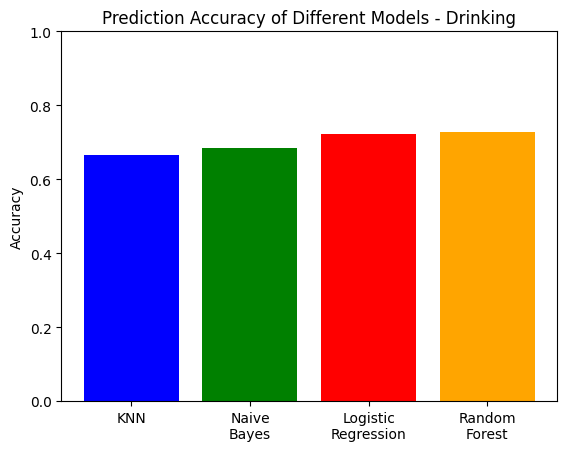

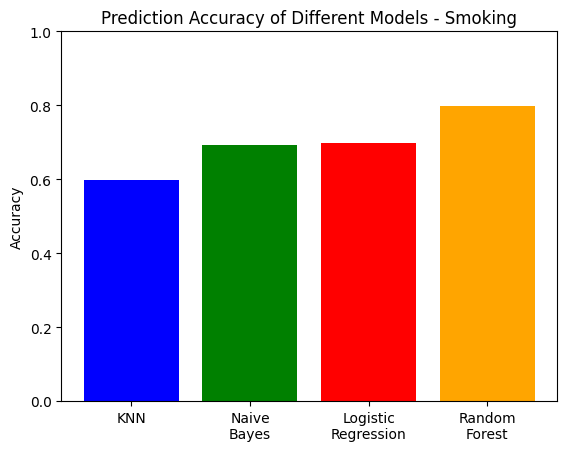

In [ ]:
accuracies_1 = [knn_accuracy_drink, nb_accuracy_drink, logreg_accuracy_drink,rf_accuracy_drink]
plt.bar(models, accuracies_1, color = ['blue', 'green', 'red','orange'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Prediction Accuracy of Different Models - Drinking')
plt.show()

accuracies_2 = [knn_accuracy_smoke, nb_accuracy_smoke, logreg_accuracy_smoke,rf_accuracy_smoke]
plt.bar(models, accuracies_2, color = ['blue', 'green', 'red','orange','orange'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Prediction Accuracy of Different Models - Smoking')
plt.show()

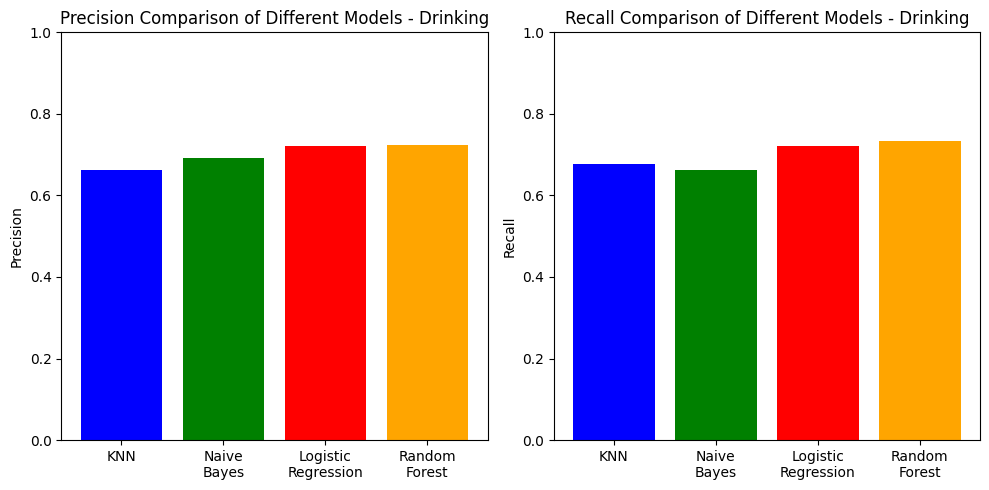

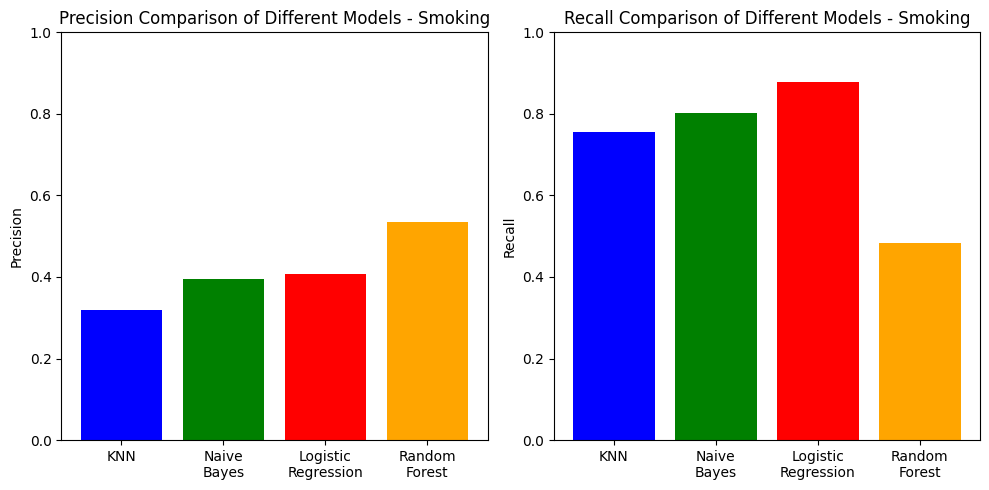

In [ ]:
knn_precision_1 = precision_score(y_drink_test, knn_pred_drink)
knn_recall_1 = recall_score(y_drink_test, knn_pred_drink)

knn_precision_2 = precision_score(y_smoke_test, knn_pred_smoke)
knn_recall_2 = recall_score(y_smoke_test, knn_pred_smoke)

nb_precision_1 = precision_score(y_drink_test, nb_pred_drink)
nb_recall_1 = recall_score(y_drink_test, nb_pred_drink)

nb_precision_2 = precision_score(y_smoke_test, nb_pred_smoke)
nb_recall_2 = recall_score(y_smoke_test, nb_pred_smoke)

logreg_precision_1 = precision_score(y_drink_test, logreg_pred_drink)
logreg_recall_1 = recall_score(y_drink_test, logreg_pred_drink)

logreg_precision_2 = precision_score(y_smoke_test, logreg_pred_smoke)
logreg_recall_2 = recall_score(y_smoke_test, logreg_pred_smoke)

rf_precision_1= precision_score(y_drink_test, rf_pred_drink)
rf_recall_1 = recall_score(y_drink_test, rf_pred_drink)

rf_precision_2= precision_score(y_smoke_test, rf_pred_smoke)
rf_recall_2 = recall_score(y_smoke_test, rf_pred_smoke)

precisions_1 = [knn_precision_1,  nb_precision_1, logreg_precision_1, rf_precision_1]
recalls_1 = [ knn_recall_1,  nb_recall_1,  logreg_recall_1, rf_recall_1]
precisions_2 = [knn_precision_2,  nb_precision_2, logreg_precision_2, rf_precision_2 ]
recalls_2 = [ knn_recall_2,  nb_recall_2,  logreg_recall_2, rf_recall_2]




fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.bar(models, precisions_1, color=['blue', 'green', 'red','orange'])
ax1.set_ylim(0, 1)
ax1.set_ylabel('Precision')
ax1.set_title('Precision Comparison of Different Models - Drinking')

ax2.bar(models, recalls_1, color=['blue', 'green', 'red','orange'])
ax2.set_ylim(0, 1)
ax2.set_ylabel('Recall')
ax2.set_title('Recall Comparison of Different Models - Drinking')

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.bar(models, precisions_2, color=['blue', 'green', 'red','orange'])
ax1.set_ylim(0, 1)
ax1.set_ylabel('Precision')
ax1.set_title('Precision Comparison of Different Models - Smoking')

ax2.bar(models, recalls_2, color=['blue', 'green', 'red','orange'])
ax2.set_ylim(0, 1)
ax2.set_ylabel('Recall')
ax2.set_title('Recall Comparison of Different Models - Smoking')

plt.tight_layout()
plt.show()

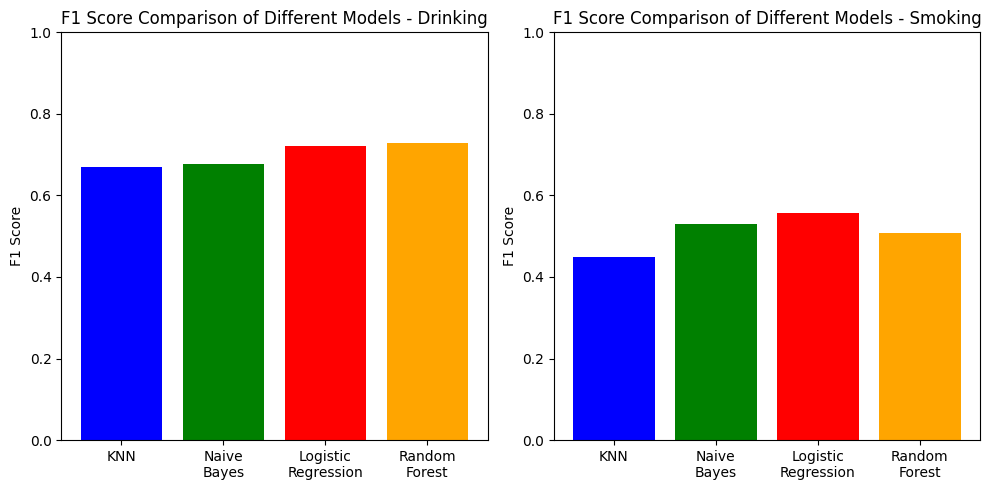

In [ ]:
knn_f1_score_1 = f1_score(y_drink_test, knn_pred_drink)

knn_f1_score_2 = f1_score(y_smoke_test, knn_pred_smoke)

nb_f1_score_1 = f1_score(y_drink_test, nb_pred_drink)

nb_f1_score_2 = f1_score(y_smoke_test, nb_pred_smoke)

logreg_f1_score_1 = f1_score(y_drink_test, logreg_pred_drink)

logreg_f1_score_2 = f1_score(y_smoke_test, logreg_pred_smoke)

rf_f1_score_1 = f1_score(y_drink_test, rf_pred_drink)

rf_f1_score_2 = f1_score(y_smoke_test, rf_pred_smoke)

f1_score_1 = [knn_f1_score_1,  nb_f1_score_1, logreg_f1_score_1, rf_f1_score_1  ]
f1_score_2 = [knn_f1_score_2,  nb_f1_score_2, logreg_f1_score_2, rf_f1_score_2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.bar(models, f1_score_1, color=['blue', 'green', 'red',"orange"])
ax1.set_ylim(0, 1)
ax1.set_ylabel('F1 Score')
ax1.set_title('F1 Score Comparison of Different Models - Drinking')

ax2.bar(models, f1_score_2, color=['blue', 'green', 'red', 'orange'])
ax2.set_ylim(0, 1)
ax2.set_ylabel('F1 Score')
ax2.set_title('F1 Score Comparison of Different Models - Smoking')

plt.tight_layout()
plt.show()



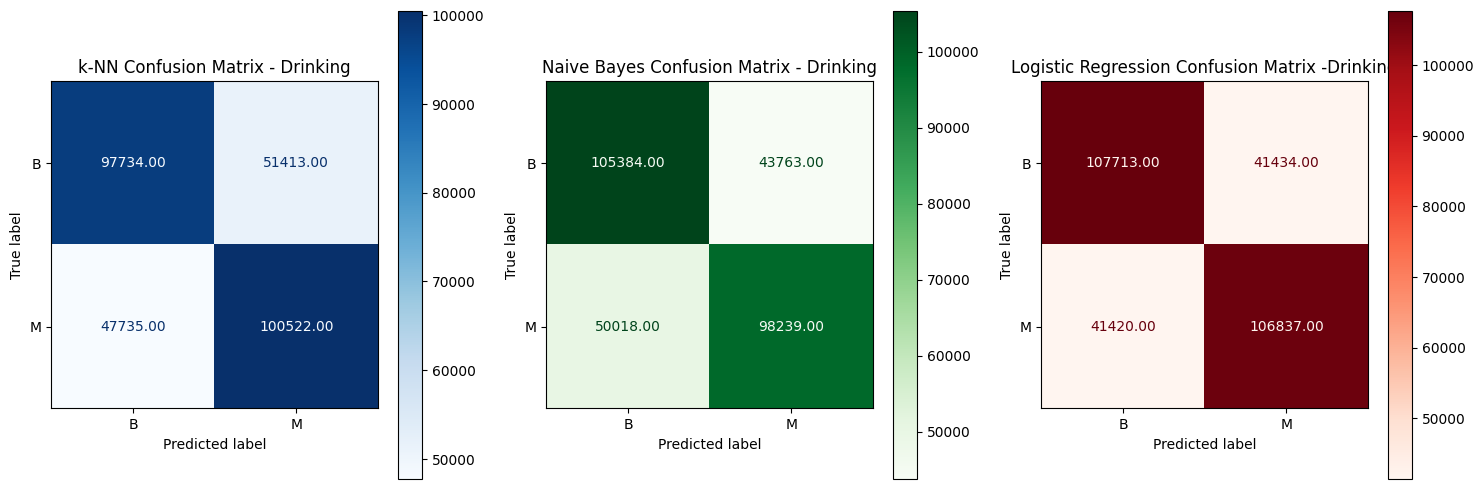

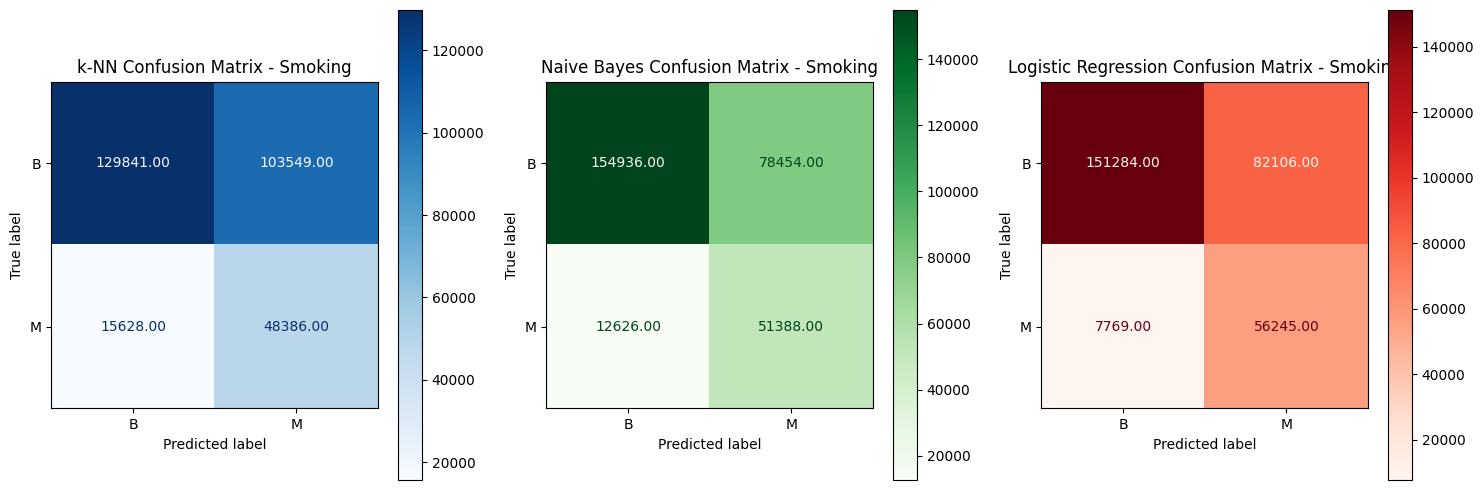

In [ ]:

knn_conf_matrix_1 = confusion_matrix(y_drink_test, knn_pred_drink)
nb_conf_matrix_1 = confusion_matrix(y_drink_test, nb_pred_drink)
logreg_conf_matrix_1 = confusion_matrix(y_drink_test, logreg_pred_drink)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

disp_knn_1 = ConfusionMatrixDisplay(knn_conf_matrix_1, display_labels = ['B', 'M'])
disp_knn_1.plot(ax = axes[0], cmap = plt.cm.Blues, values_format = '.2f')
axes[0].set_title('k-NN Confusion Matrix - Drinking')

disp_nb_1 = ConfusionMatrixDisplay(nb_conf_matrix_1, display_labels = ['B', 'M'])
disp_nb_1.plot(ax = axes[1], cmap = plt.cm.Greens, values_format = '.2f')
axes[1].set_title('Naive Bayes Confusion Matrix - Drinking')

disp_logreg_1 = ConfusionMatrixDisplay(logreg_conf_matrix_1, display_labels = ['B', 'M'])
disp_logreg_1.plot(ax = axes[2], cmap = plt.cm.Reds, values_format = '.2f')
axes[2].set_title('Logistic Regression Confusion Matrix -Drinking')

plt.tight_layout()
plt.show()

knn_conf_matrix_2 = confusion_matrix(y_smoke_test, knn_pred_smoke)
nb_conf_matrix_2 = confusion_matrix(y_smoke_test, nb_pred_smoke)
logreg_conf_matrix_2 = confusion_matrix(y_smoke_test, logreg_pred_smoke)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

disp_knn_2 = ConfusionMatrixDisplay(knn_conf_matrix_2, display_labels = ['B', 'M'])
disp_knn_2.plot(ax = axes[0], cmap = plt.cm.Blues, values_format = '.2f')
axes[0].set_title('k-NN Confusion Matrix - Smoking')

disp_nb_2 = ConfusionMatrixDisplay(nb_conf_matrix_2, display_labels = ['B', 'M'])
disp_nb_2.plot(ax = axes[1], cmap = plt.cm.Greens, values_format = '.2f')
axes[1].set_title('Naive Bayes Confusion Matrix - Smoking')

disp_logreg_2 = ConfusionMatrixDisplay(logreg_conf_matrix_2, display_labels = ['B', 'M'])
disp_logreg_2.plot(ax = axes[2], cmap = plt.cm.Reds, values_format = '.2f')
axes[2].set_title('Logistic Regression Confusion Matrix - Smoking')

plt.tight_layout()
plt.show()

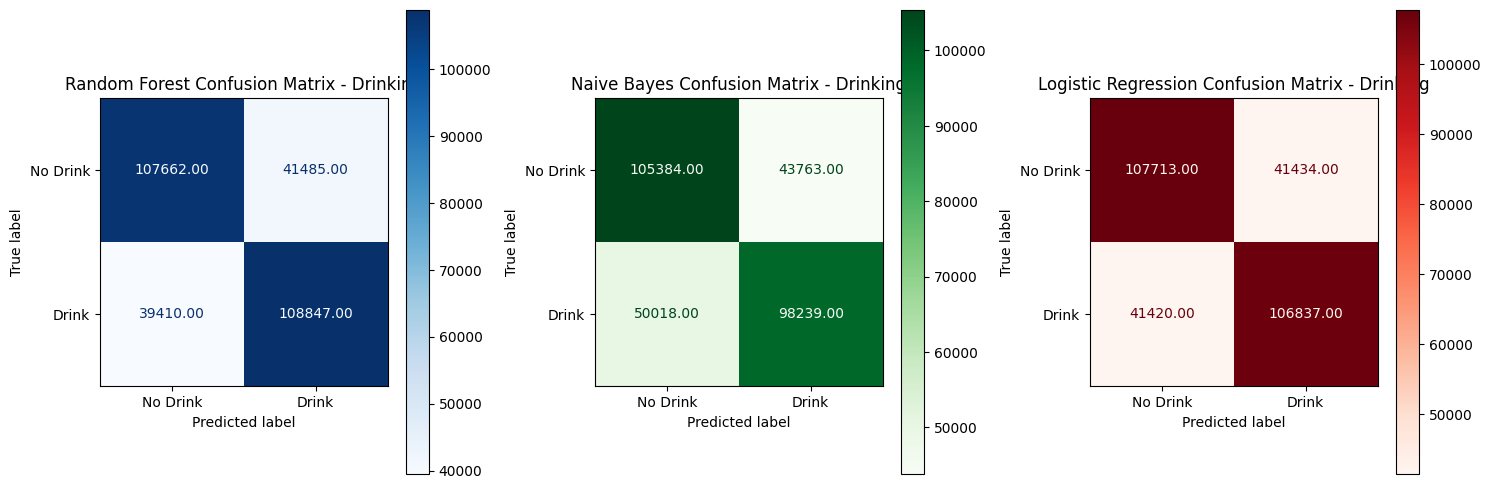

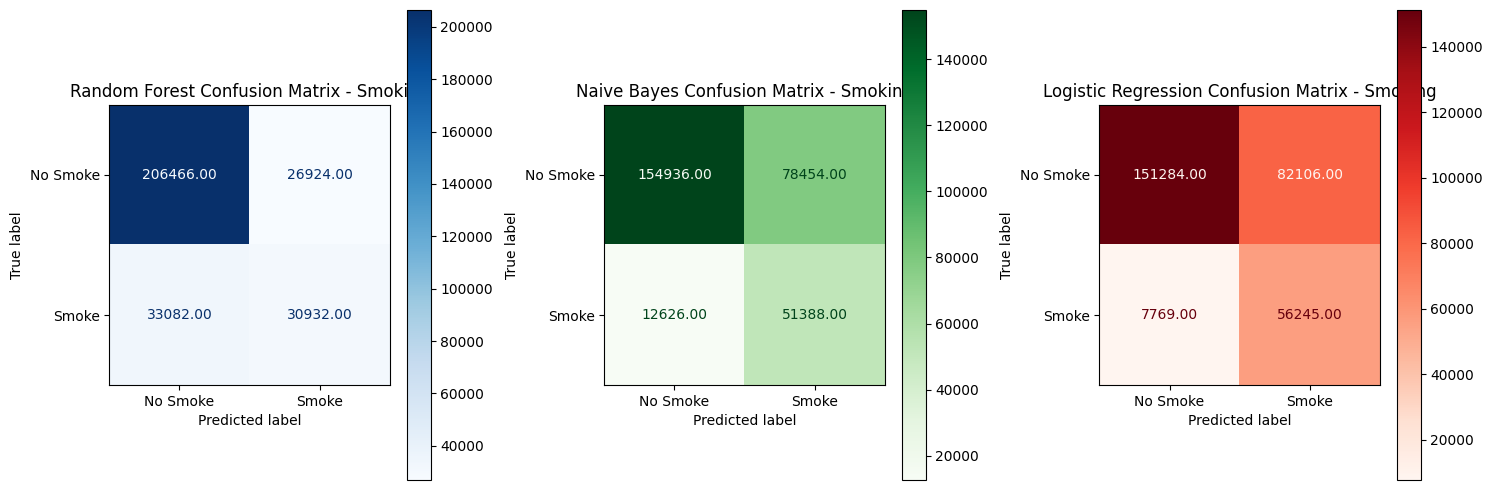

In [ ]:
# Generate confusion matrices for Drinking Prediction
rf_conf_matrix_1 = confusion_matrix(y_drink_test, rf_pred_drink)
nb_conf_matrix_1 = confusion_matrix(y_drink_test, nb_pred_drink)
logreg_conf_matrix_1 = confusion_matrix(y_drink_test, logreg_pred_drink)

# Plot for Drinking Prediction
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

disp_rf_1 = ConfusionMatrixDisplay(rf_conf_matrix_1, display_labels=['No Drink', 'Drink'])
disp_rf_1.plot(ax=axes[0], cmap=plt.cm.Blues, values_format='.2f')
axes[0].set_title('Random Forest Confusion Matrix - Drinking')

disp_nb_1 = ConfusionMatrixDisplay(nb_conf_matrix_1, display_labels=['No Drink', 'Drink'])
disp_nb_1.plot(ax=axes[1], cmap=plt.cm.Greens, values_format='.2f')
axes[1].set_title('Naive Bayes Confusion Matrix - Drinking')

disp_logreg_1 = ConfusionMatrixDisplay(logreg_conf_matrix_1, display_labels=['No Drink', 'Drink'])
disp_logreg_1.plot(ax=axes[2], cmap=plt.cm.Reds, values_format='.2f')
axes[2].set_title('Logistic Regression Confusion Matrix - Drinking')

plt.tight_layout()
plt.show()

# Generate confusion matrices for Smoking Prediction
rf_conf_matrix_2 = confusion_matrix(y_smoke_test, rf_pred_smoke)
nb_conf_matrix_2 = confusion_matrix(y_smoke_test, nb_pred_smoke)
logreg_conf_matrix_2 = confusion_matrix(y_smoke_test, logreg_pred_smoke)

# Plot for Smoking Prediction
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

disp_rf_2 = ConfusionMatrixDisplay(rf_conf_matrix_2, display_labels=['No Smoke', 'Smoke'])
disp_rf_2.plot(ax=axes[0], cmap=plt.cm.Blues, values_format='.2f')
axes[0].set_title('Random Forest Confusion Matrix - Smoking')

disp_nb_2 = ConfusionMatrixDisplay(nb_conf_matrix_2, display_labels=['No Smoke', 'Smoke'])
disp_nb_2.plot(ax=axes[1], cmap=plt.cm.Greens, values_format='.2f')
axes[1].set_title('Naive Bayes Confusion Matrix - Smoking')

disp_logreg_2 = ConfusionMatrixDisplay(logreg_conf_matrix_2, display_labels=['No Smoke', 'Smoke'])
disp_logreg_2.plot(ax=axes[2], cmap=plt.cm.Reds, values_format='.2f')
axes[2].set_title('Logistic Regression Confusion Matrix - Smoking')

plt.tight_layout()
plt.show()
